<a href="https://colab.research.google.com/github/camilacirne/ensemble_simples_vs_ponderado/blob/main/experimento_teste_sem_vazamento_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validação da Hipótese — Experimento sem Vazamento de Transfer Learning

**Dataset:** EuroSAT (imagens de satélite)
**Técnicas:** Transfer Learning + Few-Shot Learning (100-shot) + Ensemble Learning
**Modelos:** MobileNetV2 + EfficientNetB0
**Objetivo:** Verificar se a conclusão do experimento principal (H₀ não rejeitada) se mantém em um domínio desconhecido pelo ImageNet
**Hipótese:** O ensemble ponderado apresenta desempenho significativamente superior ao ensemble simples?

Imports e seed

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Instalar e carregar EuroSAT

In [ ]:
# UC Merced Land Use — imagens aéreas, fora do domínio ImageNet
dataset = load_dataset("blanchon/UC_Merced")

print("Features:", dataset['train'].features)
print("Classes:", dataset['train'].features['label'].names)
print(f"Total treino: {len(dataset['train'])}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2100 [00:00<?, ? examples/s]

Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt'])}
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Total treino: 2100


Visualização das imagens

Tipo: <class 'PIL.TiffImagePlugin.TiffImageFile'>
Tamanho: (256, 256)
Modo: RGB
Label: 0


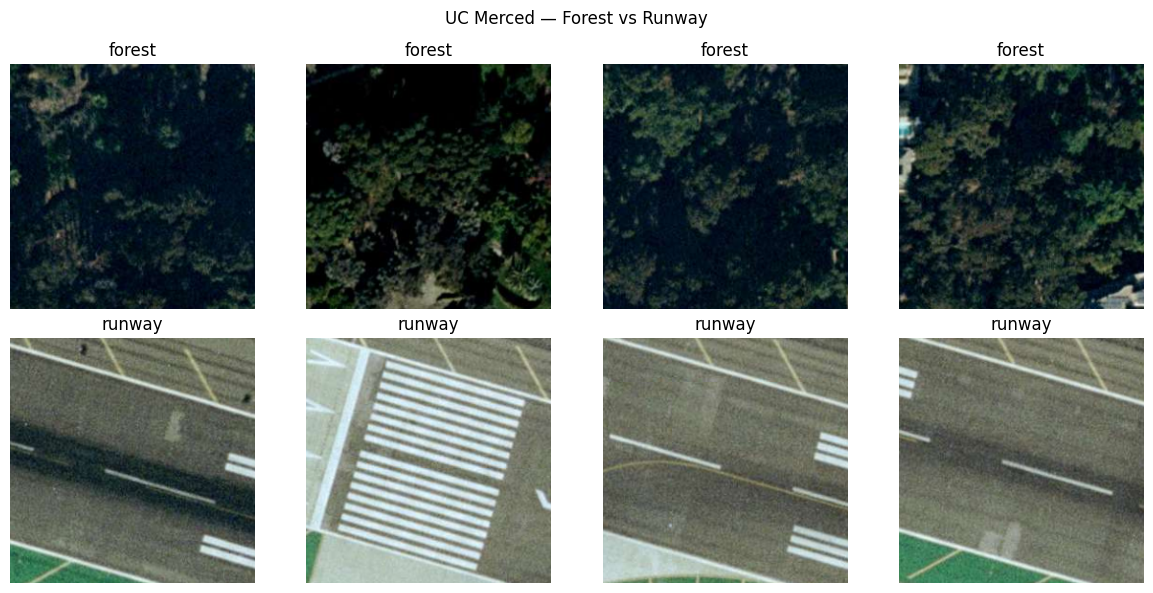

In [ ]:
# Ver formato das imagens
sample = dataset['train'][0]
img = sample['image']
print(f"Tipo: {type(img)}")
print(f"Tamanho: {img.size}")
print(f"Modo: {img.mode}")
print(f"Label: {sample['label']}")

# Visualizar algumas amostras
import matplotlib.pyplot as plt

class_names = dataset['train'].features['label'].names
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Mostrar exemplos de forest e agricultural
forest_samples = [x for x in dataset['train'] if x['label'] == 7][:4]
agricultural_samples = [x for x in dataset['train'] if x['label'] == 17][:4]

for i, sample in enumerate(forest_samples):
    axes[0][i].imshow(sample['image'])
    axes[0][i].set_title('forest')
    axes[0][i].axis('off')

for i, sample in enumerate(agricultural_samples):
    axes[1][i].imshow(sample['image'])
    axes[1][i].set_title('agricultural')
    axes[1][i].axis('off')

plt.suptitle('UC Merced — Forest vs Agricultural')
plt.tight_layout()
plt.show()

converter os dados para o formato que os modelos esperam

In [ ]:
import numpy as np
from PIL import Image

denseresidential_data  = [x for x in dataset['train'] if x['label'] == 6]
mediumresidential_data = [x for x in dataset['train'] if x['label'] == 12]

print(f"Total dense residential:  {len(denseresidential_data)}")
print(f"Total medium residential: {len(mediumresidential_data)}")

def convert_images(samples, label, target_size=(224, 224)):
    images = []
    labels = []
    for s in samples:
        img = s['image'].convert('RGB').resize(target_size)
        img_array = np.array(img).astype('float32') / 255.0
        images.append(img_array)
        labels.append(label)
    return np.array(images), np.array(labels)

x_dense,  y_dense  = convert_images(denseresidential_data,  label=0)
x_medium, y_medium = convert_images(mediumresidential_data, label=1)

x_all = np.concatenate([x_dense,  x_medium])
y_all = np.concatenate([y_dense, y_medium])

print(f"Formato x_all: {x_all.shape}")
print(f"Formato y_all: {y_all.shape}")
print(f"Classes: {np.unique(y_all, return_counts=True)}")

Total dense residential:  100
Total medium residential: 100
Formato x_all: (200, 224, 224, 3)
Formato y_all: (200,)
Classes: (array([0, 1]), array([100, 100]))


Distribuição de classes

Distribuicao das classes:
  denseresidential: 100 imagens
  mediumresidential: 100 imagens


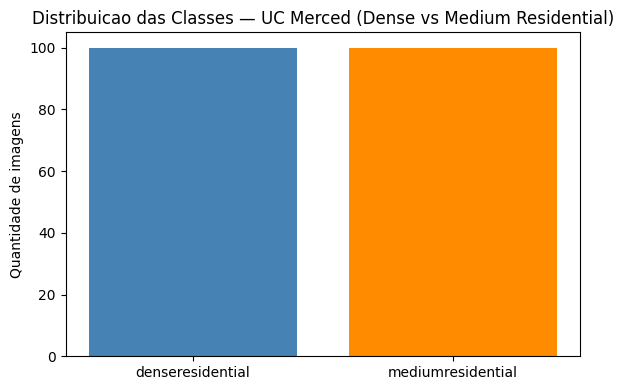

In [ ]:
import matplotlib.pyplot as plt

# Distribuição das classes
class_names_exp = ['denseresidential', 'mediumresidential']
unique, counts = np.unique(y_all, return_counts=True)

print("Distribuicao das classes:")
for name, count in zip(class_names_exp, counts):
    print(f"  {name}: {count} imagens")

plt.figure(figsize=(6, 4))
plt.bar(class_names_exp, counts, color=['steelblue', 'darkorange'])
plt.title('Distribuicao das Classes — UC Merced (Dense vs Medium Residential)')
plt.ylabel('Quantidade de imagens')
plt.tight_layout()
plt.show()

Preprocessamento separado por modelo Transfer Learning

## Modelos de Transfer Learning

Dois modelos pré-treinados no ImageNet serão utilizados como base:
- **MobileNetV2** — arquitetura leve e eficiente
- **EfficientNetB0** — arquitetura com melhor custo-benefício de acurácia

As camadas base serão congeladas (*frozen*) e apenas a cabeça de classificação será treinada no dataset few-shot.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0

IMG_SIZE = 224  # ← 224x224 para UC Merced

def preprocess_for_mobilenet(x):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x.numpy()

def preprocess_for_efficientnet(x):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x.numpy()

def create_mobilenet_model():
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_efficientnet_model():
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Modelos definidos: MobileNetV2 + EfficientNetB0 (224x224)")

Modelos definidos: MobileNetV2 + EfficientNetB0 (224x224)


 Few-shot (10 shots + seed variável)

In [ ]:
def create_few_shot_dataset(x_data, y_data, shots_per_class=70, seed=42):
    """
    Few-shot: seleciona k amostras por classe para treino.
    shots_per_class=70 → 70 para treino, 30 reservados para teste
    seed variável para garantir simulações diferentes
    """
    rng = np.random.default_rng(seed)

    selected_indices = []
    for class_label in [0, 1]:
        class_indices = np.where(y_data == class_label)[0]
        chosen = rng.choice(class_indices, size=shots_per_class, replace=False)
        selected_indices.extend(chosen)

    selected_indices = np.array(selected_indices)
    return x_data[selected_indices], y_data[selected_indices]

o conjunto de teste será fixo — as 30 imagens restantes por classe

In [ ]:
# Separar conjunto de teste fixo (30 por classe)
from sklearn.model_selection import train_test_split

x_train_pool, x_test_uc, y_train_pool, y_test_uc = train_test_split(
    x_all, y_all,
    test_size=0.3,  # 30% = 60 imagens de teste (30 dense + 30 medium residential)
    random_state=SEED,
    stratify=y_all
)

print(f"Pool de treino: {x_train_pool.shape}")
print(f"Teste fixo:     {x_test_uc.shape}")
print(f"Classes teste:  {np.unique(y_test_uc, return_counts=True)}")

Pool de treino: (140, 224, 224, 3)
Teste fixo:     (60, 224, 224, 3)
Classes teste:  (array([0, 1]), array([30, 30]))


Teste rápido da função

In [ ]:
# Teste rápido da função few-shot
x_few_test, y_few_test = create_few_shot_dataset(
    x_train_pool,   # ← usa o pool de treino, não x_all
    y_train_pool,
    shots_per_class=70,
    seed=42
)

print("Formato x_few:", x_few_test.shape)   # esperado: (140, 224, 224, 3)
print("Formato y_few:", y_few_test.shape)   # esperado: (140,)
print("Distribuicao:", np.unique(y_few_test, return_counts=True))

Formato x_few: (140, 224, 224, 3)
Formato y_few: (140,)
Distribuicao: (array([0, 1]), array([70, 70]))


Função de simulação de few shot


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np

def run_one_simulation_uc(seed, shots_per_class=70, epochs=20, batch_size=16):
    print(f"\n--- Simulacao {seed} ---")

    # 1. Few-shot dataset
    x_few, y_few = create_few_shot_dataset(
        x_train_pool,
        y_train_pool,
        shots_per_class=shots_per_class,
        seed=seed
    )

    # 2. Split estratificado
    x_train_few, x_val_few, y_train_few, y_val_few = train_test_split(
        x_few, y_few,
        test_size=0.2,
        random_state=seed,
        stratify=y_few
    )

    # 3. Preprocessamento
    x_train_mob  = preprocess_for_mobilenet(x_train_few)
    x_val_mob    = preprocess_for_mobilenet(x_val_few)
    x_train_eff  = preprocess_for_efficientnet(x_train_few)
    x_val_eff    = preprocess_for_efficientnet(x_val_few)
    x_test_mob   = preprocess_for_mobilenet(x_test_uc)
    x_test_eff   = preprocess_for_efficientnet(x_test_uc)

    # 4. Criar modelos
    mobilenet_model    = create_mobilenet_model()
    efficientnet_model = create_efficientnet_model()

    early_stop = EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )

    # 5. Treinar MobileNetV2
    history_mobile = mobilenet_model.fit(
        x_train_mob, y_train_few,
        validation_data=(x_val_mob, y_val_few),
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop], verbose=0
    )

    # 6. Treinar EfficientNetB0
    history_efficient = efficientnet_model.fit(
        x_train_eff, y_train_few,
        validation_data=(x_val_eff, y_val_few),
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop], verbose=0
    )

    # 7. Pesos dinamicos por val_loss
    val_loss_mob = history_mobile.history['val_loss'][-1]
    val_loss_eff = history_efficient.history['val_loss'][-1]
    inv_mob = 1 / (val_loss_mob + 1e-8)
    inv_eff = 1 / (val_loss_eff + 1e-8)
    total   = inv_mob + inv_eff
    w_mob   = inv_mob / total
    w_eff   = inv_eff / total

    print(f"  val_loss → MobileNet={val_loss_mob:.4f} | EfficientNet={val_loss_eff:.4f}")
    print(f"  Pesos   → MobileNet={w_mob:.3f} | EfficientNet={w_eff:.3f}")

    # 8. Previsoes
    pred_mob = mobilenet_model.predict(x_test_mob, verbose=0)
    pred_eff = efficientnet_model.predict(x_test_eff, verbose=0)

    # 9. Ensemble simples
    pred_simple   = (pred_mob + pred_eff) / 2

    # 10. Ensemble ponderado
    pred_weighted = (w_mob * pred_mob) + (w_eff * pred_eff)

    # 11. Classes finais
    y_pred_simple   = (pred_simple   >= 0.5).astype(int).reshape(-1)
    y_pred_weighted = (pred_weighted >= 0.5).astype(int).reshape(-1)

    # 12. Metricas
    simple_metrics = {
        "accuracy":  accuracy_score( y_test_uc, y_pred_simple),
        "precision": precision_score(y_test_uc, y_pred_simple,   zero_division=0),
        "recall":    recall_score(   y_test_uc, y_pred_simple,   zero_division=0),
        "f1":        f1_score(       y_test_uc, y_pred_simple,   zero_division=0),
        "w_mob": w_mob, "w_eff": w_eff
    }
    weighted_metrics = {
        "accuracy":  accuracy_score( y_test_uc, y_pred_weighted),
        "precision": precision_score(y_test_uc, y_pred_weighted, zero_division=0),
        "recall":    recall_score(   y_test_uc, y_pred_weighted, zero_division=0),
        "f1":        f1_score(       y_test_uc, y_pred_weighted, zero_division=0)
    }

    # 13. Limpar memoria
    del mobilenet_model, efficientnet_model
    tf.keras.backend.clear_session()

    return simple_metrics, weighted_metrics

print("Funcao run_one_simulation_uc definida!")

Funcao run_one_simulation_uc definida!


Teste de 1 simulação antes do loop

In [ ]:
simple_result, weighted_result = run_one_simulation_uc(
    seed=1,
    shots_per_class=70,
    epochs=20,
    batch_size=16
)

print("\nCenário 1 - Ensemble Simples:")
print(simple_result)
print("\nCenário 2 - Ensemble Ponderado:")
print(weighted_result)


--- Simulacao 1 ---
  val_loss → MobileNet=0.3120 | EfficientNet=0.6934
  Pesos   → MobileNet=0.690 | EfficientNet=0.310

Cenário 1 - Ensemble Simples:
{'accuracy': 0.85, 'precision': 0.92, 'recall': 0.7666666666666667, 'f1': 0.8363636363636363, 'w_mob': 0.6896927025044065, 'w_eff': 0.3103072974955936}

Cenário 2 - Ensemble Ponderado:
{'accuracy': 0.85, 'precision': 0.92, 'recall': 0.7666666666666667, 'f1': 0.8363636363636363}


Loop das 30 simulações

In [ ]:
import pandas as pd

results_uc = []
NUM_SIMULATIONS = 30

for sim in range(1, NUM_SIMULATIONS + 1):
    simple_metrics, weighted_metrics = run_one_simulation_uc(
        seed=sim,
        shots_per_class=70,
        epochs=20,
        batch_size=16
    )

    results_uc.append({
        "simulation": sim,
        "simple_accuracy":    simple_metrics["accuracy"],
        "simple_precision":   simple_metrics["precision"],
        "simple_recall":      simple_metrics["recall"],
        "simple_f1":          simple_metrics["f1"],
        "weighted_accuracy":  weighted_metrics["accuracy"],
        "weighted_precision": weighted_metrics["precision"],
        "weighted_recall":    weighted_metrics["recall"],
        "weighted_f1":        weighted_metrics["f1"],
        "w_mobile":           simple_metrics["w_mob"],
        "w_efficient":        simple_metrics["w_eff"]
    })

results_uc_df = pd.DataFrame(results_uc)
results_uc_df


--- Simulacao 1 ---
  val_loss → MobileNet=0.2923 | EfficientNet=0.6932
  Pesos   → MobileNet=0.703 | EfficientNet=0.297

--- Simulacao 2 ---
  val_loss → MobileNet=0.3890 | EfficientNet=0.6924
  Pesos   → MobileNet=0.640 | EfficientNet=0.360

--- Simulacao 3 ---
  val_loss → MobileNet=0.2813 | EfficientNet=0.6931
  Pesos   → MobileNet=0.711 | EfficientNet=0.289

--- Simulacao 4 ---
  val_loss → MobileNet=0.2556 | EfficientNet=0.6927
  Pesos   → MobileNet=0.730 | EfficientNet=0.270

--- Simulacao 5 ---
  val_loss → MobileNet=0.2130 | EfficientNet=0.6921
  Pesos   → MobileNet=0.765 | EfficientNet=0.235

--- Simulacao 6 ---
  val_loss → MobileNet=0.4300 | EfficientNet=0.6924
  Pesos   → MobileNet=0.617 | EfficientNet=0.383

--- Simulacao 7 ---
  val_loss → MobileNet=0.1656 | EfficientNet=0.6923
  Pesos   → MobileNet=0.807 | EfficientNet=0.193

--- Simulacao 8 ---
  val_loss → MobileNet=0.2681 | EfficientNet=0.6936
  Pesos   → MobileNet=0.721 | EfficientNet=0.279

--- Simulacao 9 ---
  v

## Verificação de Independência entre Simulações

In [ ]:
from itertools import combinations
import numpy as np

# Verificar sobreposição entre subconjuntos de treino das simulações
all_indices = {}
for sim in range(1, 31):
    rng = np.random.default_rng(sim)
    indices = []
    for class_label in [0, 1]:
        class_indices = np.where(y_train_pool == class_label)[0]  # ← era y_train_filtered
        chosen = rng.choice(class_indices, size=70, replace=False)  # ← era 100
        indices.extend(chosen.tolist())
    all_indices[sim] = set(indices)

# Sobreposição entre pares de simulações
overlaps = []
for s1, s2 in combinations(range(1, 31), 2):
    overlap = len(all_indices[s1] & all_indices[s2])
    overlaps.append(overlap)

print(f"Sobreposição média entre simulações: {np.mean(overlaps):.1f} imagens")
print(f"Sobreposição máxima: {np.max(overlaps)} imagens")
print(f"Sobreposição mínima: {np.min(overlaps)} imagens")

# Verificar vazamento treino→teste
print("\nVerificando vazamento treino→teste...")
train_hashes = set(map(lambda x: hash(x.tobytes()), x_train_pool))  # ← era x_train_filtered
test_hashes  = set(map(lambda x: hash(x.tobytes()), x_test_uc))     # ← era x_test_filtered
vazamento = len(train_hashes & test_hashes)
print(f"Vazamento treino→teste: {vazamento} imagens")
print("(esperado: 0 — split estratificado garante separacao)")

Sobreposição média entre simulações: 4.0 imagens
Sobreposição máxima: 11 imagens
Sobreposição mínima: 0 imagens

Verificando vazamento treino→teste...
Vazamento treino→teste: 0 imagens
(esperado: 0 — CIFAR-10 garante separacao por design)


Verificação de Domínio: Impacto da Similaridade Visual

In [ ]:
## Teste 2 — Verificação de Domínio: Impacto da Similaridade Visual
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Pares de classes para testar
pares_teste = [
    (0, 6, 'airplane vs frog'),    # muito distintos — já sabemos que funciona
    (8, 4, 'ship vs deer'),        # muito distintos
    (1, 7, 'automobile vs horse'), # moderadamente distintos
    (3, 5, 'cat vs dog'),          # nosso caso original — alta similaridade
]

def run_domain_test(class_a, class_b, nome, n_sims=10, shots=100, epochs=20, batch=16):
    print(f"\n=== {nome} ===")

    # Filtrar classes
    y_tr = y_train.reshape(-1)
    y_te = y_test.reshape(-1)

    tr_filter = np.where((y_tr == class_a) | (y_tr == class_b))[0]
    te_filter = np.where((y_te == class_a) | (y_te == class_b))[0]

    x_tr = x_train[tr_filter].astype('float32')
    y_tr = np.where(y_tr[tr_filter] == class_a, 0, 1)
    x_te = x_test[te_filter].astype('float32')
    y_te = np.where(y_te[te_filter] == class_a, 0, 1)

    accs_simples    = []
    accs_ponderados = []

    for sim in range(1, n_sims + 1):
        # Few-shot
        rng = np.random.default_rng(sim)
        indices = []
        for cl in [0, 1]:
            ci = np.where(y_tr == cl)[0]
            indices.extend(rng.choice(ci, size=shots, replace=False).tolist())
        x_few = x_tr[indices]
        y_few = y_tr[indices]

        # Split estratificado
        from sklearn.model_selection import train_test_split
        x_trn, x_val, y_trn, y_val = train_test_split(
            x_few, y_few, test_size=0.2, random_state=sim, stratify=y_few
        )

        # Preprocess
        x_trn_m = preprocess_for_mobilenet(x_trn)
        x_val_m = preprocess_for_mobilenet(x_val)
        x_trn_e = preprocess_for_efficientnet(x_trn)
        x_val_e = preprocess_for_efficientnet(x_val)
        x_te_m  = preprocess_for_mobilenet(x_te)
        x_te_e  = preprocess_for_efficientnet(x_te)

        # Modelos
        mob = create_mobilenet_model()
        eff = create_efficientnet_model()

        from tensorflow.keras.callbacks import EarlyStopping
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        mob.fit(x_trn_m, y_trn, validation_data=(x_val_m, y_val),
                epochs=epochs, batch_size=batch, callbacks=[es], verbose=0)
        eff.fit(x_trn_e, y_trn, validation_data=(x_val_e, y_val),
                epochs=epochs, batch_size=batch, callbacks=[es], verbose=0)

        # Pesos
        vl_m = mob.history.history['val_loss'][-1]
        vl_e = eff.history.history['val_loss'][-1]
        inv_m = 1 / (vl_m + 1e-8)
        inv_e = 1 / (vl_e + 1e-8)
        total = inv_m + inv_e
        w_m = inv_m / total
        w_e = inv_e / total

        # Previsões
        pm = mob.predict(x_te_m, verbose=0)
        pe = eff.predict(x_te_e, verbose=0)

        y_simple   = ((pm + pe) / 2 >= 0.5).astype(int).reshape(-1)
        y_weighted = ((w_m * pm + w_e * pe) >= 0.5).astype(int).reshape(-1)

        accs_simples.append(accuracy_score(y_te, y_simple))
        accs_ponderados.append(accuracy_score(y_te, y_weighted))

        import tensorflow as tf
        del mob, eff
        tf.keras.backend.clear_session()

    print(f"  Simples:    {np.mean(accs_simples):.4f} ± {np.std(accs_simples):.4f}")
    print(f"  Ponderado:  {np.mean(accs_ponderados):.4f} ± {np.std(accs_ponderados):.4f}")
    print(f"  Diferença:  {np.mean(accs_ponderados) - np.mean(accs_simples):+.4f}")

    return {
        'par': nome,
        'simples':   round(np.mean(accs_simples), 4),
        'ponderado': round(np.mean(accs_ponderados), 4),
        'diferenca': round(np.mean(accs_ponderados) - np.mean(accs_simples), 4)
    }

# Rodar os 4 pares
resultados_dominio = []
for class_a, class_b, nome in pares_teste:
    r = run_domain_test(class_a, class_b, nome, n_sims=10)
    resultados_dominio.append(r)

# Tabela final
df_dominio = pd.DataFrame(resultados_dominio)
df_dominio.columns = ['Par de Classes', 'Ensemble Simples', 'Ensemble Ponderado', 'Diferença']
print("\n=== RESULTADO FINAL ===")
print(df_dominio.to_string(index=False))


=== airplane vs frog ===
  Simples:    0.9597 ± 0.0035
  Ponderado:  0.9602 ± 0.0035
  Diferença:  +0.0005

=== ship vs deer ===
  Simples:    0.9678 ± 0.0034
  Ponderado:  0.9678 ± 0.0035
  Diferença:  -0.0000

=== automobile vs horse ===
  Simples:    0.9779 ± 0.0029
  Ponderado:  0.9776 ± 0.0031
  Diferença:  -0.0003

=== cat vs dog ===
  Simples:    0.7247 ± 0.0108
  Ponderado:  0.7248 ± 0.0116
  Diferença:  +0.0001

=== RESULTADO FINAL ===
     Par de Classes  Ensemble Simples  Ensemble Ponderado  Diferença
   airplane vs frog            0.9598              0.9602     0.0005
       ship vs deer            0.9678              0.9678    -0.0000
automobile vs horse            0.9779              0.9776    -0.0003
         cat vs dog            0.7247              0.7248     0.0001


Estatísticas descritivas das 30 **simulações**

In [ ]:
results_df.describe()
results_df.to_csv("results_30_simulations.csv", index=False)

Resumo comparativo dos cenários

In [ ]:
print("=" * 45)
print("ENSEMBLE SIMPLES")
print(f"  Acurácia média:   {results_df['simple_accuracy'].mean():.4f}")
print(f"  Desvio padrão:    {results_df['simple_accuracy'].std():.4f}")

print("\nENSEMBLE PONDERADO")
print(f"  Acurácia média:   {results_df['weighted_accuracy'].mean():.4f}")
print(f"  Desvio padrão:    {results_df['weighted_accuracy'].std():.4f}")

print("\nPESOS MÉDIOS USADOS")
print(f"  MobileNet:        {results_df['w_mobile'].mean():.3f}")
print(f"  EfficientNet:     {results_df['w_efficient'].mean():.3f}")
print("=" * 45)

ENSEMBLE SIMPLES
  Acurácia média:   0.7231
  Desvio padrão:    0.0157

ENSEMBLE PONDERADO
  Acurácia média:   0.7237
  Desvio padrão:    0.0154

PESOS MÉDIOS USADOS
  MobileNet:        0.572
  EfficientNet:     0.428


Teste t pareado (hipótese)

In [ ]:
from scipy.stats import ttest_rel, t
import numpy as np

t_stat, p_value = ttest_rel(
    results_df["weighted_accuracy"],
    results_df["simple_accuracy"]
)

diff = results_df["weighted_accuracy"] - results_df["simple_accuracy"]
n = len(diff)
ci = t.interval(0.95, df=n-1, loc=diff.mean(), scale=diff.std()/np.sqrt(n))

print(f"  IC 95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

alpha = 0.05

print("=" * 45)
print("TESTE T PAREADO — H₀ vs H₁")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value:     {p_value:.4f}")
print(f"  Alpha:       {alpha}")
print()
if p_value < alpha:
    print(" Rejeita H₀ — diferença significativa.")
    print(" O ensemble ponderado é significativamente melhor.")
else:
    print("  Falha em rejeitar H₀ — sem diferença significativa.")
print("=" * 45)

  IC 95%: [-0.0000, 0.0013]
TESTE T PAREADO — H₀ vs H₁
  T-statistic: 1.9190
  P-value:     0.0649
  Alpha:       0.05

  Falha em rejeitar H₀ — sem diferença significativa.


Boxplot — Comparação de Acurácia

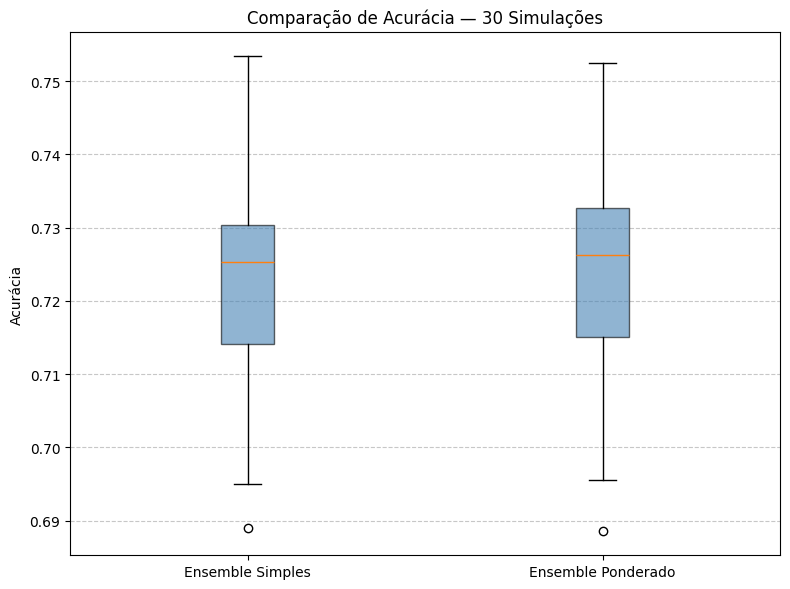

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(
    [results_df["simple_accuracy"], results_df["weighted_accuracy"]],
    tick_labels=["Ensemble Simples", "Ensemble Ponderado"],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
plt.ylabel("Acurácia")
plt.title("Comparação de Acurácia — 30 Simulações")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Acurácia por Simulação

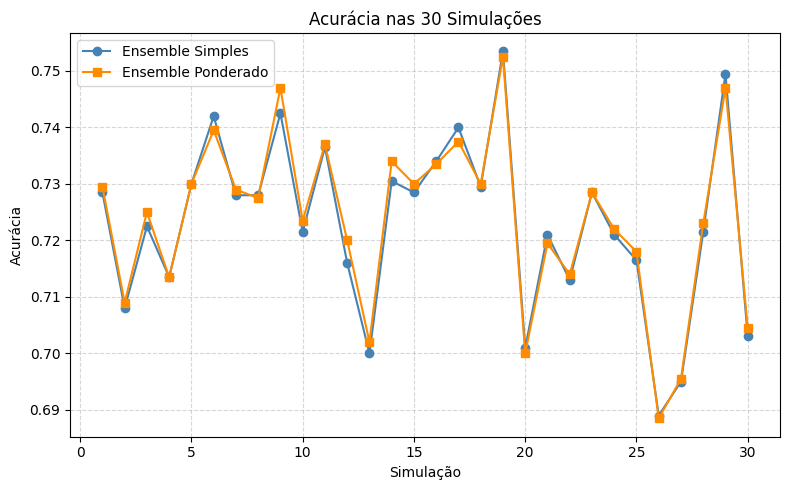

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["simulation"], results_df["simple_accuracy"],
         marker='o', label='Ensemble Simples', color='steelblue')
plt.plot(results_df["simulation"], results_df["weighted_accuracy"],
         marker='s', label='Ensemble Ponderado', color='darkorange')
plt.xlabel("Simulação")
plt.ylabel("Acurácia")
plt.title("Acurácia nas 30 Simulações")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Média das Métricas por Cenário

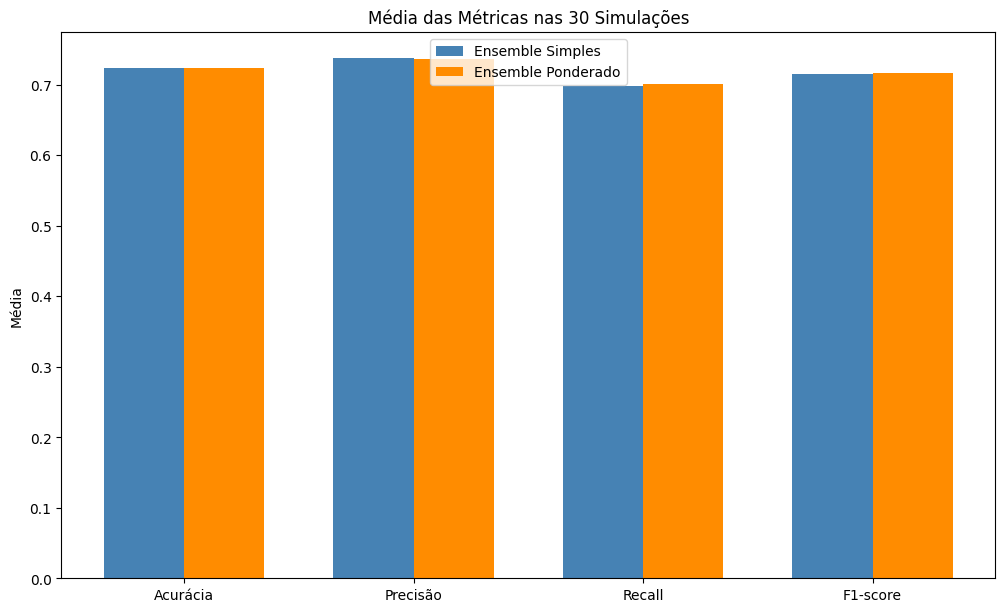

In [ ]:
metrics = ["accuracy", "precision", "recall", "f1"]

simple_means = [
    results_df["simple_accuracy"].mean(),
    results_df["simple_precision"].mean(),
    results_df["simple_recall"].mean(),
    results_df["simple_f1"].mean()
]

weighted_means = [
    results_df["weighted_accuracy"].mean(),
    results_df["weighted_precision"].mean(),
    results_df["weighted_recall"].mean(),
    results_df["weighted_f1"].mean()
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, simple_means, width, label="Ensemble Simples", color='steelblue')
plt.bar(x + width/2, weighted_means, width, label="Ensemble Ponderado", color='darkorange')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.xticks(x, ["Acurácia", "Precisão", "Recall", "F1-score"])
plt.ylabel("Média")
plt.title("Média das Métricas nas 30 Simulações")
plt.legend()
plt.grid(axis="y")

plt.show()

Distribuição da Diferença de Acurácia

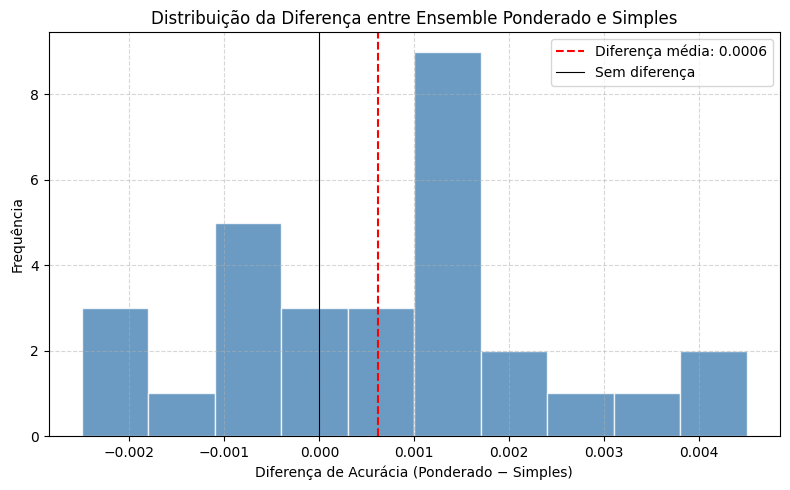

In [ ]:
results_df["accuracy_difference"] = (
    results_df["weighted_accuracy"] - results_df["simple_accuracy"]
)

plt.figure(figsize=(8, 5))
plt.hist(results_df["accuracy_difference"], bins=10,
         color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(results_df["accuracy_difference"].mean(),
            color='red', linestyle='--', label=f'Diferença média: {results_df["accuracy_difference"].mean():.4f}')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, label='Sem diferença')  # ← novo
plt.xlabel("Diferença de Acurácia (Ponderado − Simples)")
plt.ylabel("Frequência")
plt.title("Distribuição da Diferença entre Ensemble Ponderado e Simples")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Tabela Resumo Final

In [ ]:
summary_table = pd.DataFrame({
    "Métrica":            ["Acurácia", "Precisão", "Recall", "F1-score"],
    "Ensemble Simples":   [round(v, 4) for v in simple_means],
    "Ensemble Ponderado": [round(v, 4) for v in weighted_means],
    "Diferença":          [round(w - s, 4) for s, w in zip(simple_means, weighted_means)]
})

summary_table

,Métrica,Ensemble Simples,Ensemble Ponderado,Diferença
0,Acurácia,0.7231,0.7237,0.0006
1,Precisão,0.7376,0.7368,-0.0008
2,Recall,0.6983,0.7014,0.0031
3,F1-score,0.7156,0.7170,0.0014


Matriz de Confusão — Melhor Simulação

Melhor simulação: 19 | Acurácia: 0.7525


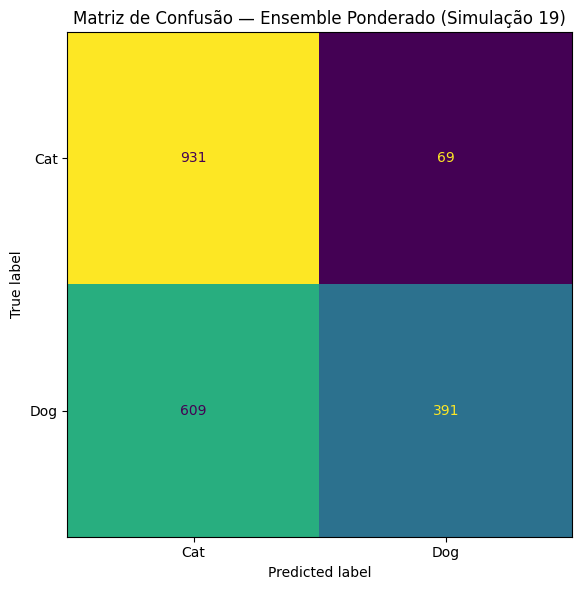

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pega a simulação com maior acurácia ponderada
best_sim = results_df["weighted_accuracy"].idxmax()
best_seed = results_df.loc[best_sim, "simulation"]

print(f"Melhor simulação: {best_seed} | Acurácia: {results_df.loc[best_sim, 'weighted_accuracy']:.4f}")

# Roda novamente só para pegar as predições
x_few_b, y_few_b = create_few_shot_dataset(
    x_train_filtered, y_train_filtered,
    shots_per_class=100, seed=best_seed
)

x_few_mobile_b    = preprocess_for_mobilenet(x_few_b)
x_few_efficient_b = preprocess_for_efficientnet(x_few_b)
x_test_mobile_b    = preprocess_for_mobilenet(x_test_filtered)
x_test_efficient_b = preprocess_for_efficientnet(x_test_filtered)

mob_b = create_mobilenet_model()
eff_b = create_efficientnet_model()

h_mob = mob_b.fit(x_few_mobile_b,    y_few_b, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
h_eff = eff_b.fit(x_few_efficient_b, y_few_b, epochs=10, batch_size=16, validation_split=0.2, verbose=0)

val_loss_m = h_mob.history['val_loss'][-1]
val_loss_e = h_eff.history['val_loss'][-1]
inv_m = 1 / (val_loss_m + 1e-8)
inv_e = 1 / (val_loss_e + 1e-8)
total = inv_m + inv_e
w_m = inv_m / total
w_e = inv_e / total

pred_m = mob_b.predict(x_test_mobile_b,    verbose=0)
pred_e = eff_b.predict(x_test_efficient_b, verbose=0)
pred_w = (w_m * pred_m) + (w_e * pred_e)
y_pred_best = (pred_w >= 0.5).astype(int).reshape(-1)

cm = confusion_matrix(y_test_filtered, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title(f"Matriz de Confusão — Ensemble Ponderado (Simulação {best_seed})")
plt.tight_layout()
plt.show()

del mob_b, eff_b
tf.keras.backend.clear_session()

In [ ]:
# Shapiro-Wilk
from scipy.stats import shapiro
stat, p_shapiro = shapiro(results_df["weighted_accuracy"] - results_df["simple_accuracy"])
print(f"Shapiro-Wilk: W={stat:.4f}, p={p_shapiro:.4f}")

# Wilcoxon
from scipy.stats import wilcoxon
stat_w, p_wilcoxon = wilcoxon(results_df["weighted_accuracy"], results_df["simple_accuracy"])
print(f"Wilcoxon: W={stat_w:.4f}, p={p_wilcoxon:.4f}")

# Cohen's d
diff = results_df["weighted_accuracy"] - results_df["simple_accuracy"]
cohens_d = diff.mean() / diff.std()
print(f"Cohen's d: {cohens_d:.4f}")


Shapiro-Wilk: W=0.9683, p=0.4943
Wilcoxon: W=112.5000, p=0.0652
Cohen's d: 0.3504


Testes estatísticos não paredos

In [ ]:
from scipy.stats import shapiro, mannwhitneyu

# Shapiro-Wilk NÃO pareado — testa normalidade de cada grupo separadamente
stat_s, p_s = shapiro(results_df["simple_accuracy"])
stat_w, p_w = shapiro(results_df["weighted_accuracy"])
print(f"Shapiro-Wilk Simples:    W={stat_s:.4f}, p={p_s:.4f}")
print(f"Shapiro-Wilk Ponderado:  W={stat_w:.4f}, p={p_w:.4f}")

# Mann-Whitney NÃO pareado
u_stat, p_mw = mannwhitneyu(
    results_df["weighted_accuracy"],
    results_df["simple_accuracy"]
)
print(f"Mann-Whitney: U={u_stat:.4f}, p={p_mw:.4f}")

# Cohen's d NÃO pareado
mean_s = results_df["simple_accuracy"].mean()
mean_w = results_df["weighted_accuracy"].mean()
std_s  = results_df["simple_accuracy"].std()
std_w  = results_df["weighted_accuracy"].std()
pooled_std = np.sqrt((std_s**2 + std_w**2) / 2)
cohens_d_unpaired = (mean_w - mean_s) / pooled_std
print(f"Cohen's d NÃO pareado: d={cohens_d_unpaired:.4f}")

In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu

# Teste t NÃO pareado
t_ind, p_ind = ttest_ind(
    results_df["weighted_accuracy"],
    results_df["simple_accuracy"]
)
print(f"t NÃO pareado: t={t_ind:.4f}, p={p_ind:.4f}")

# Mann-Whitney NÃO pareado
u_stat, p_mw = mannwhitneyu(
    results_df["weighted_accuracy"],
    results_df["simple_accuracy"]
)
print(f"Mann-Whitney: U={u_stat:.4f}, p={p_mw:.4f}")